# Caracterización del espacio de parámetros de la ley de Paris-Erdogan

**Anexo de código del TFM.** Pronóstico de crecimiento de grietas por fatiga (PHM Data Challenge 2019).
Carlos J. Bravo I.

Este informe determina qué puede establecerse sobre los parámetros de mecánica de la fractura a
partir de los datos del certamen, y qué de ello resulta transferible al módulo físicamente informado
(componente **b**) y al predictor multi-paso (componente **c**) de las cuatro configuraciones.

El procedimiento consta de dos etapas consecutivas: en primer lugar se comprueba si existen valores
publicados para el material del ensayo, la aleación de aluminio 2024-T3; en caso negativo, se
identifican mediante algoritmos metaheurísticos. El resultado de la primera etapa condiciona el
resto del informe, por lo que se aborda en primer lugar.

El resultado de la identificación no es el que el planteamiento inicial anticipaba, y esa
discrepancia es en sí misma un hallazgo. El coeficiente resulta transferible entre especímenes,
pero **el exponente no queda determinado**: el perfil de verosimilitud es casi plano y la
comprobación independiente arroja un intervalo de ±1.30 sobre un valor central de 2.57. Lo que este
informe transfiere a las configuraciones no es, por tanto, un par de constantes numéricas, sino la
caracterización del espacio admisible: qué ley aplicar, en qué ventana se mueve el exponente, cómo
se reparte la variación entre especímenes, qué formas funcionales deben descartarse por singulares y
cuántos anclajes exige el integrador. El apartado 7 recapitula ese reparto.

## Contenido

| Apartado | Contenido |
|---|---|
| 1 | Descripción del problema y disponibilidad de valores publicados |
| 2 | Modelo: espacio de soluciones, función objetivo y restricciones |
| 3 | Análisis: complejidad y tamaño del espacio de búsqueda |
| 4 | Diseño de la búsqueda: algoritmos evaluados y reformulación del problema |
| 5 | Resultados experimentales |
| 6 | Parámetros resultantes |
| 7 | Conclusiones y limitaciones |

> **Alcance del resultado.** El análisis acota el exponente, pero no lo determina de forma unívoca:
> deja dos candidatos admisibles, *m* = 2.00 y *m* = 2.25. La elección entre ambos no se resuelve con
> el criterio de ajuste empleado en este informe, sino con un criterio de robustez frente a la
> incertidumbre del coeficiente, aplicado sobre los especímenes de entrenamiento al configurar el
> modelo. El valor adoptado es ***m* = 2.00**; el apartado 6 justifica esa elección y expone las
> consecuencias de no acompañarlo de su coeficiente correspondiente.

### Procedimiento de identificación

El diagrama siguiente resume el recorrido completo del informe antes de entrar en su detalle. La
identificación se desarrolla en tres etapas encadenadas. La primera compara seis algoritmos
metaheurísticos sobre un problema sencillo, un espécimen y dos parámetros, para saber cuál es más
fiable. La segunda ajusta las siete leyes candidatas a los cuatro especímenes de calibración a la vez,
con un exponente común a todos ellos y un coeficiente propio de cada uno, y de ella sale la ley
adoptada. La tercera elige el exponente de esa ley por su capacidad de predecir la parte de la curva
que falta, y no por la calidad del ajuste.

En azul figuran los pasos que ejecutan los algoritmos metaheurísticos o el barrido del exponente; en
verde, el cálculo del coeficiente de cada espécimen por búsqueda en rejilla, que no emplea
metaheurísticos; y en naranja, el resultado de cada etapa. La flecha entre los dos
primeros marcos indica que la comparación de la etapa 1 motiva la reformulación de la etapa 2. La caja de borde discontinuo es una comprobación previa que no produce parámetros; la línea discontinua indica que su conclusión justifica el criterio de la etapa 3.

![Procedimiento de identificación de los parámetros de la ley de crecimiento](../docs/img/procedimiento_calibracion.png)

### Reproducción de los resultados

Los resultados que se presentan proceden de una cadena de cinco pasos que se ejecuta en este orden:
la calibración propiamente dicha, que cubre las etapas A a E; los dos barridos posteriores, de
anclajes y de exponente, que corresponden a las etapas F y G; la generación de los parámetros
resultantes; y la exportación de figuras. Solo el primer paso es costoso, del orden de dos horas y
media, mientras que los cuatro restantes no llegan en conjunto a quince segundos.

Los cuatro pasos posteriores no son opcionales. Todos ellos derivan de la salida de la calibración,
de modo que quedan desfasados en cuanto esta se repite, y omitirlos dejaría tablas nuevas junto a
parámetros antiguos. Los comandos concretos figuran en el fichero de instrucciones del paquete.

In [1]:
import json, sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
RAIZ = Path("/home/carlos/TFMProject")
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, NullFormatter
from IPython.display import display

pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": .3, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})

from physics_calibration import priors
from physics_calibration.calibrate import stage_e_loglog, CALIBRATION_SPECIMENS, FITTABLE
from physics_calibration.data import ALL_SPECIMENS, load_curves
from physics_calibration.metaheuristics import ALGORITHMS
from physics_calibration.models import (LAWS, predict_mm,
                                        _A_MIN_M, _A_MAX_M, _RATE_MAX_M_PER_CYCLE)
from physics_calibration.objectives import phm_penalty, _LARGE

RESULTS = RAIZ / "physics_calibration" / "results"
print("Resultados registrados:", ", ".join(sorted(p.name for p in RESULTS.glob("stage_*"))))
print("\nEspecímenes de CALIBRACION:", CALIBRATION_SPECIMENS)
print("Especímenes con >=4 medidas (usados en la comparativa de algoritmos):", FITTABLE)

MARCA_DE_AGUA = "Carlos J. Bravo (2026)"

def marca_de_agua(fig, texto=MARCA_DE_AGUA):
    fig.text(0.995, 0.004, texto, fontsize=8, color="0.45", alpha=0.38,
             ha="right", va="bottom", fontweight="bold")
    return fig


Resultados registrados: stage_a_algorithm_benchmark.csv, stage_b_pooled_best.json, stage_b_pooled_runs.csv, stage_c_profile_m.json, stage_d_transfer.csv, stage_d_transfer_curves.json, stage_e_loglog.json, stage_f_anchor_sweep.csv, stage_g_exponent_sweep.csv

Especímenes de CALIBRACION: ('T1', 'T3', 'T4', 'T6')
Especímenes con >=4 medidas (usados en la comparativa de algoritmos): ('T1', 'T3', 'T4', 'T6', 'T7', 'T8')


## 1. Descripción del problema

### 1.1 Parámetros a identificar

La ley de Paris-Erdogan describe la velocidad de crecimiento de una grieta por fatiga:

$$\frac{da}{dN} = C\,(\Delta K)^{m}, \qquad \Delta K = \Delta\sigma\,Y\sqrt{\pi a}$$

donde *a* es la longitud de grieta, *N* el número de ciclos, Δ*K* el rango del factor de intensidad
de tensiones, Δσ el rango de tensión aplicado e *Y* el factor geométrico. Las constantes *C* y *m*
dependen del material y de la geometría, y son las que el módulo físicamente informado necesita para
extrapolar más allá del último ciclo con señal disponible.

El problema es, por tanto, de identificación de parámetros: determinar los valores que hacen que la
curva integrada reproduzca las curvas *a*(*N*) medidas ópticamente.

### 1.2 Disponibilidad de valores publicados

Se revisó el texto de los artículos recogidos en `Papers/` en busca de constantes de Paris, Walker,
Forman y NASGRO acompañadas de valores numéricos. No existen valores publicados para estos
especímenes, circunstancia que los tres equipos premiados del certamen declaran de forma expresa:

* **Kong *et al.*** (2.º puesto) declaran que sus constantes no pudieron determinarse porque
  dependen de las propiedades del material del espécimen:

  > *the constants C₀, γ and m could not be determined because they depend on the material
  > properties of the specimen*

  Las ajustan mediante algoritmo genético y no publican los valores obtenidos.
* **Youn *et al.*** (1.º puesto) descartan los modelos físicos por faltarles la geometría y las
  propiedades del material:

  > *the shape of the initial crack, specimen geometry, and material properties*

  En su lugar recurren a un procedimiento empírico de traslado de curvas.
* **Rao *et al.*** (3.º puesto) emplean la ventana genérica de metales *m* ∈ [2, 4],
  *C* ∈ [10⁻¹³, 10⁻¹¹], y ajustan igualmente por algoritmo genético.

El único dato específico de la aleación 2024-T3 presente en el corpus es la función de cierre de
Elber y Schijve, que se incorpora con sus valores publicados y no se somete a ajuste.

In [2]:
for fuente, v in priors.LITERATURE_REFERENCE.items():
    print(f"- {fuente}\n    {v}")
print("\nFunción de cierre de Elber/Schijve para 2024-T3 (U = 0.55 + 0.35R + 0.1R^2):")
for R in (0.0, 0.0476, 0.1, 0.3, 0.5):
    print(f"    R = {R:.4f}  ->  U = {priors.elber_schijve_closure(R):.4f}")
print("\nNo se dispone de constantes publicadas utilizables para estos especímenes,")
print("por lo que se procede a su identificación mediante algoritmos metaheurísticos.")


- Dourado & Viana (2019), Al 2024-T3 coupons (Menan & Henaff 2010), air
    {'C': 5.008e-10, 'm': 3.859, 'note': 'units not recoverable from the paper; do not use as-is'}
- Metals 13(8):1134 (2023), AA 2024-T4, modified CT, R = -1
    {'C': 5.75e-08, 'm': 3.09}
- Rao et al. (2021) after Li, Wang & Gong (2012), generic metals
    {'C_range': (1e-13, 1e-11), 'm_range': (2.0, 4.0)}

Función de cierre de Elber/Schijve para 2024-T3 (U = 0.55 + 0.35R + 0.1R^2):
    R = 0.0000  ->  U = 0.5500
    R = 0.0476  ->  U = 0.5669
    R = 0.1000  ->  U = 0.5860
    R = 0.3000  ->  U = 0.6640
    R = 0.5000  ->  U = 0.7500

No se dispone de constantes publicadas utilizables para estos especímenes,
por lo que se procede a su identificación mediante algoritmos metaheurísticos.


### 1.3 Datos disponibles

El conjunto consta de ocho especímenes con su curva *a*(*N*) medida ópticamente. El reparto entre
ajuste y evaluación viene impuesto por el protocolo del certamen y condiciona la validez de todos
los resultados posteriores:

* **T1, T3, T4 y T6** constituyen el conjunto de calibración y son los únicos que intervienen en la
  identificación agrupada.
* **T2 y T5** quedan excluidos del ajuste: disponen de dos medidas de grieta no nula cada uno, que
  no bastan para restringir una ley de dos a cinco parámetros. T5 es, además, el espécimen atípico
  reconocido por la organización del certamen.
* **T7 y T8** se reservan para evaluación y no intervienen en la identificación de los exponentes ni
  del coeficiente poblacional.

In [3]:
curves = load_curves(ALL_SPECIMENS)
display(pd.DataFrame([{
    "espécimen": c.name,
    "papel": ("CALIBRACION" if c.name in CALIBRATION_SPECIMENS
              else "evaluación" if c.name in ("T7", "T8") else "excluido del ajuste"),
    "medidas no nulas": len(c.crack_mm), "con señal PZT": c.n_observed,
    "a inicial (mm)": c.a0_mm, "a final (mm)": c.final_crack_mm,
    "ciclo inicial": int(c.n0), "ciclo final": int(c.cycles[-1]),
    "R": round(c.stress_ratio, 4),
    "carga": "variable" if c.is_variable_amplitude else "constante",
} for c in curves.values()]))

print("Bloques de carga decodificados (n_ciclos, Smax, Smin) [MPa]:")
print("  T1-T7 (constante):", curves["T1"].load_block.tolist())
print("  T8    (variable) :", curves["T8"].load_block.tolist())
print("\nEl bloque de T8 se deriva del perfil publicado con el propio conjunto de datos,")
print("no de la transcripción del artículo: 500 ciclos a 90.00 MPa y 500 a 100.21 MPa,")
print("1000 ciclos exactos por bloque.")


,espécimen,papel,medidas no nulas,con señal PZT,a inicial (mm),a final (mm),ciclo inicial,ciclo final,R,carga
0,T1,CALIBRACION,6,6,2.18,7.46,60000,70766,0.0476,constante
1,T2,excluido del ajuste,2,2,3.25,4.95,70033,72000,0.0476,constante
2,T3,CALIBRACION,7,7,2.57,6.93,57038,66510,0.0476,constante
3,T4,CALIBRACION,7,7,1.61,7.24,60200,75045,0.0476,constante
4,T5,excluido del ajuste,2,2,2.70,3.64,51000,56000,0.0476,constante
5,T6,CALIBRACION,5,5,0.82,5.08,60078,73211,0.0476,constante
6,T7,evaluación,6,2,2.07,7.22,44054,55031,0.0476,constante
7,T8,evaluación,7,2,1.94,5.52,74883,100774,0.0503,variable


Bloques de carga decodificados (n_ciclos, Smax, Smin) [MPa]:
  T1-T7 (constante): [[1.0, 100.21, 4.77]]
  T8    (variable) : [[500.0, 90.0, 4.77], [500.0, 100.21, 4.77]]

El bloque de T8 se deriva del perfil publicado con el propio conjunto de datos,
no de la transcripción del artículo: 500 ciclos a 90.00 MPa y 500 a 100.21 MPa,
1000 ciclos exactos por bloque.


La disponibilidad de anclajes es el factor que limita la extrapolación. El espécimen T7 deja de
disponer de ficheros PZT tras el ciclo 47022 y el T8 tras el 76931, lo que reduce a **dos** las
medidas de grieta no nula utilizables para anclar la predicción. Este presupuesto, impuesto por el
protocolo, se analiza cuantitativamente en el apartado 5.6.

## 2. Modelo

### 2.1 Representación del espacio de soluciones

Una solución candidata es un vector de números reales con los parámetros de una ley de crecimiento.
Se implementaron siete formulaciones bajo una interfaz común, de dos a cinco parámetros, de modo que
la elección de la ley constituya un resultado experimental y no una suposición de partida.

Dos decisiones de representación condicionan el comportamiento de la búsqueda:

**Escala logarítmica para el coeficiente.** El valor de *C* es del orden de 10⁻⁹ y su intervalo
plausible abarca seis décadas. Una búsqueda poblacional en escala lineal concentraría toda su
población en el extremo superior del intervalo, por lo que se busca log₁₀*C*, con lo que el espacio
queda uniformemente explorable.

**Amplitud deliberada de las cotas.** Los intervalos de búsqueda son considerablemente más amplios
que la ventana genérica de metales empleada por Rao *et al.* Esta decisión responde a dos motivos.
Con *Y* = 1 el coeficiente absorbe la compliancia de la junta remachada, de manera que la ventana
publicada para probetas de laboratorio no permite reproducir las velocidades observadas. Además, *C*
y *m* presentan una anticorrelación casi perfecta sobre la denominada cresta logarítmica,
cuya ecuación es log₁₀*C* ≈ log₁₀(d*a*/d*N*) − *m*·log₁₀(Δ*K*), y que por sí sola abarca unas ocho
décadas de *C*. Un
intervalo más estrecho situaría el óptimo contra el límite de búsqueda y convertiría el exponente
identificado en un artefacto de las cotas en lugar de una medida obtenida de los datos.

In [4]:
filas = []
for nombre, ley in LAWS.items():
    filas.append({
        "ley": nombre,
        "parámetros": ", ".join(ley.param_names),
        "dimensión": len(ley.param_names),
        "en log10": ", ".join(ley.log_params),
        "cotas": " | ".join(f"{p}∈[{lo:g},{hi:g}]"
                            for p, (lo, hi) in zip(ley.param_names, ley.bounds)),
    })
display(pd.DataFrame(filas))


,ley,parámetros,dimensión,en log10,cotas
0,paris,"C, m",2,C,"C∈[-20,-5] | m∈[1,8]"
1,walker,"C0, m, gamma",3,C0,"C0∈[-20,-5] | m∈[1,8] | gamma∈[0,1]"
2,walker_closure,"C0, m, gamma",3,C0,"C0∈[-20,-5] | m∈[1,8] | gamma∈[0,1]"
3,forman,"C, m, Kc",3,C,"C∈[-20,-5] | m∈[1,8] | Kc∈[20,200]"
4,paris_hole,"C, m, Kt, lambda_h",4,C,"C∈[-20,-5] | m∈[1,8] | Kt∈[1,8] | lambda_h∈[0...."
5,walker_hole,"C0, m, gamma, Kt, lambda_h",5,C0,"C0∈[-20,-5] | m∈[1,8] | gamma∈[0,1] | Kt∈[1,8]..."
6,forman_hole,"C, m, Kc, Kt, lambda_h",5,C,"C∈[-20,-5] | m∈[1,8] | Kc∈[20,200] | Kt∈[1,8] ..."


### 2.2 Factor geométrico

La documentación del conjunto de datos sitúa el origen de la grieta en el agujero avellanado de la
primera fila de remaches:

> *initiates at the countersunk hole in the first row*

El factor geométrico
correspondiente parte de la concentración de tensiones del agujero y decae con la longitud de
grieta, conforme al problema de Bowie.

La adopción de *Y* = 1 no es, por tanto, físicamente exacta, y sus consecuencias son medibles: bajo
esa hipótesis la velocidad debería acelerar como *a*^(*m*/2), mientras que la aceleración observada
en T3, T6 y T8 es sensiblemente más plana, lo que desplaza el exponente ajustado por debajo del
mínimo admisible. Para cuantificar ese efecto se incorporaron las variantes `*_hole`, que emplean el
subrogado fenomenológico

$$Y(a) = 1 + (K_t - 1)\,e^{-a/\lambda_h}$$

Dicho subrogado se declara como tal y no pretende reproducir la solución de Bowie. Su función es
verificar la coherencia física del ajuste, según se detalla en el apartado 5.3.3, y no servir de
base a la extrapolación.

### 2.3 Función objetivo

La elección de la función de pérdida condiciona los parámetros resultantes, por lo que se
implementaron tres y se reportan de forma conjunta.

| Clave | Definición | Función |
|---|---|---|
| `rmse` | $\sqrt{\frac{1}{n}\sum_i (\hat a_i - a_i)^2}$ sobre las medidas no nulas | Objetivo principal. Físicamente neutro: determina qué par (*C*, *m*) satisface mejor la ley |
| `kong` | $\frac{1}{n}\sum_i i^2\,(\hat a_i - a_i)^2$, Ec. 12 de Kong *et al.* (2020) | Sobrepondera las grietas tardías y de mayor longitud |
| `phm` | $S=\sum_i T(i)A(i)M(i)$ sobre longitudes normalizadas | Penalización oficial del certamen: asimétrica y sensible a la monotonía |

La identificación se ejecuta bajo `rmse` y los resultados se reportan además bajo las otras dos
funciones. Ajustar bajo un criterio y reportar bajo otro permite cuantificar en qué medida la
asimetría de riesgo del certamen desplaza la física identificada, magnitud que constituye un
resultado por sí misma.

La evaluación es vectorizada en todos los casos: la función recibe una matriz de candidatos
(*n*, *d*) y devuelve *n* valores, de modo que los algoritmos poblacionales evalúan su población
completa en una sola llamada.

### 2.4 Implementación de las restricciones

Las soluciones no admisibles no se descartan, sino que se penalizan, de manera que el paisaje de
búsqueda mantenga su carácter informativo y guíe al optimizador en lugar de presentar
discontinuidades. Se emplean tres mecanismos, que actúan en niveles distintos:

1. **Restricciones de caja**, impuestas por construcción. Cada algoritmo recorta sus candidatos al
   intervalo de búsqueda declarado para cada parámetro, por lo que ninguna evaluación se realiza
   fuera del dominio admisible.
2. **Restricciones de estado en el integrador.** Un juego de parámetros inestable no debe producir
   valores `inf` ni `NaN` durante la integración por Runge-Kutta, por lo que el estado se acota: la
   longitud de grieta se mantiene en el intervalo [1 µm, 20 mm] y la velocidad por debajo de
   10⁻² m/ciclo. El límite superior de 20 mm equivale a casi el triple de la grieta más larga medida
   en el conjunto de datos (7.46 mm en T1), de modo que no interfiere con ninguna trayectoria
   físicamente significativa, pero mantiene acotada una trayectoria divergente y conserva su
   penalización dentro de un rango interpretable.
3. **Penalización de valores no finitos.** Los resultados que aun así resulten no finitos se
   sustituyen por `_LARGE = 1e12`, valor peor que cualquier solución admisible pero finito y, por
   tanto, ordenable por el optimizador.

La celda siguiente verifica el funcionamiento de los tres mecanismos sometiendo al integrador a
juegos de parámetros extremos.

In [5]:
print(f"Cotas de estado del integrador:")
print(f"  a mínima  = {_A_MIN_M*1e3:g} mm")
print(f"  a máxima  = {_A_MAX_M*1e3:g} mm   (2.7 veces la grieta mayor medida, 7.46 mm en T1)")
print(f"  da/dN máx = {_RATE_MAX_M_PER_CYCLE:g} m/ciclo")
print(f"  valor sustitutivo de lo no finito = {_LARGE:g}\n")

cur = curves["T1"]
ensayo = np.array([
    [-8.50, 2.00],
    [-5.00, 2.00],
    [-8.50, 7.00],
])
pred = predict_mm(LAWS["paris"], ensayo, cur.a0_mm, cur.delta_cycles, cur.load_block)
for i, (lc, m) in enumerate(ensayo):
    p = pred[:, i]
    print(f"  log10C={lc:6.2f}  m={m:.2f}  ->  a final = {p[-1]:8.3f} mm   "
          f"finito: {np.all(np.isfinite(p))}   penalización = "
          f"{float(phm_penalty(p[None, :], cur.crack_mm, cur.final_crack_mm)[0]):.3g}")
print(f"\nNinguna predicción supera el tope de {_A_MAX_M*1e3:g} mm: "
      f"máximo observado {pred.max():.3f} mm")
print("\nLos tres mecanismos operan según lo descrito en el apartado 2.4: los juegos de")
print("parámetros no admisibles producen penalizaciones elevadas pero finitas, de modo")
print("que el optimizador puede ordenarlos y el paisaje de búsqueda permanece continuo.")


Cotas de estado del integrador:
  a mínima  = 0.001 mm
  a máxima  = 20 mm   (2.7 veces la grieta mayor medida, 7.46 mm en T1)
  da/dN máx = 0.01 m/ciclo
  valor sustitutivo de lo no finito = 1e+12

  log10C= -8.50  m=2.00  ->  a final =    5.775 mm   finito: True   penalización = 27.6
  log10C= -5.00  m=2.00  ->  a final =   20.000 mm   finito: True   penalización = 2.45e+03
  log10C= -8.50  m=7.00  ->  a final =   20.000 mm   finito: True   penalización = 2.45e+03

Ninguna predicción supera el tope de 20 mm: máximo observado 20.000 mm

Los tres mecanismos operan según lo descrito en el apartado 2.4: los juegos de
parámetros no admisibles producen penalizaciones elevadas pero finitas, de modo
que el optimizador puede ordenarlos y el paisaje de búsqueda permanece continuo.


### 2.5 Estructura jerárquica del ajuste

Un único espécimen no permite identificar la ley. Los parámetros *C* y *m* están ligados por la
cresta logarítmica, y cada espécimen del PHM 2019 abarca únicamente Δ*K* ≈ 5–15 MPa·√m repartidos en
cinco a siete medidas: ajustarlos de forma independiente produce un error de ajuste reducido con un
exponente esencialmente arbitrario, sin valor como distribución a priori del módulo físico.

El ajuste agrupado resuelve esta limitación reproduciendo la estructura que la mecánica de la
fractura atribuye a estos parámetros. Los exponentes (*m*, γ, *K*c) son constantes del material y de
la geometría, compartidas por todos los especímenes de la misma aleación y unión, mientras que el
coeficiente *C* absorbe la dispersión entre probetas debida al ajuste del remache, la geometría
local y el punto de iniciación. Un único vector de búsqueda contiene, en consecuencia,

$$\theta = [\, m,\ \gamma,\ K_c,\ \log_{10}C_1,\ \log_{10}C_2,\ \dots,\ \log_{10}C_S \,]$$

Los tres primeros componentes son compartidos por todas las probetas y los *S* restantes son uno por
probeta,
y el objetivo es la media de las pérdidas por espécimen. Esta estructura coincide con la que requiere
el módulo físicamente informado: los exponentes compartidos pasan a constituir física fija, y el
log₁₀*C* de cada espécimen se convierte en el único escalar que el codificador convolucional debe
estimar a partir de las ondas de Lamb.

## 3. Análisis del problema

### 3.1 Complejidad y tamaño del espacio de búsqueda

El problema es de optimización continua, no lineal y no convexa. Cada evaluación exige integrar
numéricamente una ecuación diferencial mediante Runge-Kutta a lo largo de decenas de miles de
ciclos, por lo que el coste computacional no reside en la dimensión del problema sino en el número
de evaluaciones.

No existe solución en forma cerrada: la ley es no lineal en *m*, el objetivo no es convexo y, según
se documenta en el apartado 5.1, resulta multimodal en la formulación directa. Estas propiedades
motivan el recurso a algoritmos metaheurísticos.

La contabilización del espacio de búsqueda requiere discretizarlo, dado su carácter continuo.
Adoptando una resolución de 10⁻³ en cada variable normalizada, equivalente a mil valores
distinguibles por eje, se obtienen las magnitudes siguientes.

In [6]:
RESOL = 1000
S = len(CALIBRATION_SPECIMENS)

filas = []
for nombre, ley in LAWS.items():
    d_ind = len(ley.param_names)
    d_pool = (d_ind - 1) + S
    d_proy = d_ind - 1
    filas.append({
        "ley": nombre,
        "d (por espécimen)": d_ind, "espacio": f"{float(RESOL**d_ind):.1e}",
        "d (agrupado)": d_pool, "espacio ": f"{float(RESOL**d_pool):.1e}",
        "d (proyectado)": d_proy, "espacio  ": f"{float(RESOL**d_proy):.1e}",
    })
display(pd.DataFrame(filas))

print(f"Con S = {S} especímenes de calibración y {RESOL} valores por variable.")
print(f"\nEl caso peor, forman_hole agrupado, son {float(RESOL**(4+S)):.1e} combinaciones:")
print("enumerarlas a 1 millón de evaluaciones por segundo llevaría "
      f"{RESOL**(4+S)/1e6/3.15e7:.1e} años.")
print("\nLa proyección de variables (apartado 4.2) reduce la dimensión efectiva a 1-4,")
print("que es donde una metaheurística converge de forma fiable y donde compararlas")
print("entre sí significa algo.")


,ley,d (por espécimen),espacio,d (agrupado),espacio,d (proyectado),espacio
0,paris,2,1.0e+06,5,1.0e+15,1,1.0e+03
1,walker,3,1.0e+09,6,1.0e+18,2,1.0e+06
2,walker_closure,3,1.0e+09,6,1.0e+18,2,1.0e+06
3,forman,3,1.0e+09,6,1.0e+18,2,1.0e+06
4,paris_hole,4,1.0e+12,7,1.0e+21,3,1.0e+09
5,walker_hole,5,1.0e+15,8,1.0e+24,4,1.0e+12
6,forman_hole,5,1.0e+15,8,1.0e+24,4,1.0e+12


Con S = 4 especímenes de calibración y 1000 valores por variable.

El caso peor, forman_hole agrupado, son 1.0e+24 combinaciones:
enumerarlas a 1 millón de evaluaciones por segundo llevaría 3.2e+10 años.

La proyección de variables (apartado 4.2) reduce la dimensión efectiva a 1-4,
que es donde una metaheurística converge de forma fiable y donde compararlas
entre sí significa algo.


### 3.2 Contraste independiente del modelo

Antes de interpretar cualquier resultado de optimización conviene disponer de una estimación que no
dependa de la ley elegida ni del optimizador empleado. A tal efecto se estima d*a*/d*N* por
diferencias finitas y se realiza una regresión de log(d*a*/d*N*) frente a log(Δ*K*), en la que la
pendiente corresponde a *m* y la ordenada en el origen a log *C*.

In [7]:
loglog = stage_e_loglog(curves)
p = loglog["pooled"]
print(f"Ajuste global:  m = {p['m']:.3f} +/- {p['m_ci95']:.3f} (IC 95 %)")
print(f"                C = {p['C']:.3e}   R2 = {p['r2']:.3f}   n = {p['n']} puntos")
print(f"                dispersión residual = {p['residual_sd_dex']:.3f} dex "
      f"(factor {10**p['residual_sd_dex']:.2f})")
print(f"\nDeltaK abarca {p['delta_k_min']:.2f}-{p['delta_k_max']:.2f} MPa*sqrt(m), esto es "
      f"{np.log10(p['delta_k_max']/p['delta_k_min']):.2f} decadas.")
print("Ese recorrido reducido explica la amplitud del intervalo de confianza.")
print("\nExponente ajustado espécimen a espécimen:")
display(pd.DataFrame(loglog["per_specimen"]).T)


Ajuste global:  m = 2.566 +/- 1.302 (IC 95 %)
                C = 8.729e-10   R2 = 0.332   n = 32 puntos
                dispersión residual = 0.298 dex (factor 1.99)

DeltaK abarca 6.75-13.87 MPa*sqrt(m), esto es 0.31 decadas.
Ese recorrido reducido explica la amplitud del intervalo de confianza.

Exponente ajustado espécimen a espécimen:


,m,C,n
T1,5.275530,1.852399e-12,5.0
T3,1.334920,1.762251e-08,6.0
T4,3.835422,5.668046e-11,6.0
T6,1.641975,1.183473e-08,4.0
T7,2.958713,3.722822e-10,5.0
T8,-0.109895,1.919355e-07,6.0


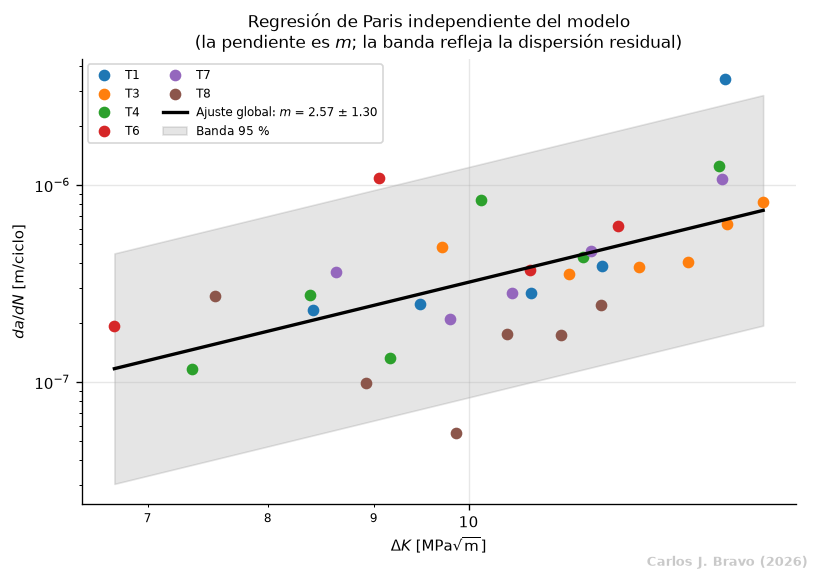

In [8]:
df = pd.DataFrame(loglog["points"])
fig, ax = plt.subplots(figsize=(6.8, 4.8))
for spec, g in df.groupby("specimen"):
    ax.loglog(g["delta_k_MPa_sqrt_m"], g["da_dn_m_per_cycle"], "o", ms=6, label=spec)
xs = np.linspace(df["delta_k_MPa_sqrt_m"].min(), df["delta_k_MPa_sqrt_m"].max(), 50)
ys = p["C"] * xs ** p["m"]
banda = 10 ** (1.96 * p["residual_sd_dex"])
ax.loglog(xs, ys, "k-", lw=2, label=f"Ajuste global: $m$ = {p['m']:.2f} ± {p['m_ci95']:.2f}")
ax.fill_between(xs, ys / banda, ys * banda, color="k", alpha=.10, label="Banda 95 %")
ax.set_xlabel(r"$\Delta K$ [MPa$\sqrt{\mathrm{m}}$]"); ax.set_ylabel(r"$da/dN$ [m/ciclo]")
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_formatter(ScalarFormatter())
ax.tick_params(axis="x", which="minor", labelsize=7)
ax.set_title("Regresión de Paris independiente del modelo\n"
             "(la pendiente es $m$; la banda refleja la dispersión residual)", fontsize=10)
ax.legend(fontsize=7, ncol=2)
fig.tight_layout(); marca_de_agua(fig)
plt.show()


El intervalo de confianza resultante es de ±1.30 sobre un valor central de 2.57, amplitud que se
explica por el estrecho recorrido de Δ*K*, limitado a 0.31 décadas. Todos los especímenes se
ensayaron bajo el mismo espectro de carga y las grietas cubren un rango reducido de longitudes, de
modo que la pendiente está mal condicionada por el diseño del ensayo y no por deficiencia del
método de estimación.

> Este hecho condiciona la interpretación de todos los resultados posteriores: **el exponente no es
> determinable a partir de estos datos**. Cualquier resultado que aparente fijarlo con precisión
> elevada debe examinarse a la luz de esta limitación.

## 4. Diseño de la búsqueda

### 4.1 Algoritmos evaluados y presupuesto

Se implementaron seis algoritmos metaheurísticos con una interfaz común, de modo que la elección del
optimizador constituya un resultado experimental y no una suposición heredada. La comparación es
pertinente porque los trabajos del certamen que ajustan parámetros físicos emplean algoritmo
genético sin justificar la elección.

La equidad de la comparación queda garantizada por construcción: un contador envuelve la función
objetivo, interrumpe la ejecución exactamente al agotarse el presupuesto de evaluaciones y registra
la mejor solución encontrada hasta cada instante. Ningún algoritmo puede, por tanto, obtener ventaja
mediante un número mayor de evaluaciones.

In [9]:
print("Algoritmos implementados:", ", ".join(ALGORITHMS))
print("\nTodos comparten:")
print("  - la misma función objetivo vectorizada,")
print("  - el mismo presupuesto de evaluaciones, contado sobre la función objetivo y no")
print("    sobre las iteraciones del algoritmo,")
print("  - las mismas cotas,")
print("  - y la misma semilla por ejecución.")
print("\nEl pulido local (Nelder-Mead acotado) se aplica en las etapas B a D, cuyo objeto es")
print("obtener el mejor juego de parámetros, y se omite en la comparativa A, que contrasta")
print("las búsquedas globales entre sí.")


Algoritmos implementados: sa, acor, vns, de, pso, ga

Todos comparten:
  - la misma función objetivo vectorizada,
  - el mismo presupuesto de evaluaciones, contado sobre la función objetivo y no
    sobre las iteraciones del algoritmo,
  - las mismas cotas,
  - y la misma semilla por ejecución.

El pulido local (Nelder-Mead acotado) se aplica en las etapas B a D, cuyo objeto es
obtener el mejor juego de parámetros, y se omite en la comparativa A, que contrasta
las búsquedas globales entre sí.


### 4.2 Proyección de variables

La formulación directa, consistente en buscar simultáneamente el exponente compartido y los cuatro
coeficientes en un espacio de cinco a seis dimensiones, resultó multimodal y no reproducible:
ejecuciones independientes del mismo algoritmo convergían a óptimos distintos.

El problema admite, sin embargo, una descomposición. Fijados los exponentes, el coeficiente de cada
espécimen puede determinarse por separado, y la pérdida es unimodal en log₁₀*C* dado que la longitud
de grieta es monótona en el coeficiente. Proyectando esa variable mediante una búsqueda en rejilla
vectorizada, técnica conocida como *variable projection*, los algoritmos metaheurísticos sólo han
de explorar los uno a cuatro exponentes compartidos.

La rejilla emplea 48 puntos y tres refinamientos sucesivos, cada uno de ellos restringido a un
entorno de ±2 pasos alrededor del mejor valor precedente, con lo que la resolución final supera
ampliamente la de la rejilla inicial sin incurrir en su coste.

Tras la reformulación, quince ejecuciones independientes arrojaron un error de 0.4278 mm con
dispersión en la cuarta cifra significativa. El apartado 5.2 cuantifica el efecto de esta
reformulación sobre el rendimiento comparado de los algoritmos.

## 5. Resultados experimentales

### 5.1 Comparativa de algoritmos sobre la formulación directa

La comparativa comprende 180 ejecuciones por algoritmo, resultantes de combinar tres leyes, seis
especímenes y diez semillas, con 20 000 evaluaciones de la función objetivo cada una. La métrica empleada no es el error
absoluto, que mezclaría especímenes de dificultad dispar, sino la diferencia respecto del mejor
óptimo alcanzado por cualquier algoritmo en ese par (ley, espécimen); un valor de 0.0 indica que la
ejecución alcanzó el mejor óptimo conocido.

In [10]:
bench = pd.read_csv(RESULTS / "stage_a_algorithm_benchmark.csv")
bench["brecha_mm"] = bench["objective_rmse_mm"] - bench.groupby(
    ["law", "specimen"])["objective_rmse_mm"].transform("min")
tabla = (bench.groupby("algorithm")
         .agg(óptimos_exactos=("brecha_mm", lambda v: int((v < 1e-6).sum())),
              ejecuciones=("brecha_mm", "size"),
              brecha_mediana=("brecha_mm", "median"),
              brecha_p90=("brecha_mm", lambda v: v.quantile(0.9)),
              peor_brecha=("brecha_mm", "max"),
              seg_por_ejecución=("seconds", "mean"))
         .sort_values("óptimos_exactos", ascending=False).round(5))
display(tabla)
de_, ga_ = tabla.loc["de"], tabla.loc["ga"]
print(f"Evolución diferencial : {de_.óptimos_exactos:3.0f}/180 óptimos, peor brecha {de_.peor_brecha:.3f} mm")
print(f"Algoritmo genético    : {ga_.óptimos_exactos:3.0f}/180 óptimos, peor brecha {ga_.peor_brecha:.3f} mm")
print(f"\nLa evolución diferencial alcanza el óptimo {de_.óptimos_exactos/ga_.óptimos_exactos:.1f} veces más a menudo que el")
print(f"   con un peor caso {ga_.peor_brecha/de_.peor_brecha:.1f}x menor y coste comparable.")


,óptimos_exactos,ejecuciones,brecha_mediana,brecha_p90,peor_brecha,seg_por_ejecución
algorithm,,,,,,
de,132,180,0.00000,0.08326,0.19729,3.43373
acor,104,180,0.00000,0.10457,0.25934,6.50602
pso,101,180,0.00000,0.10950,0.27676,3.25106
ga,49,180,0.00005,0.10487,0.25347,3.46277
sa,18,180,0.00011,0.07781,0.22049,10.76927
vns,0,180,0.22818,0.81416,1.37657,10.93714


Evolución diferencial : 132/180 óptimos, peor brecha 0.197 mm
Algoritmo genético    :  49/180 óptimos, peor brecha 0.253 mm

La evolución diferencial alcanza el óptimo 2.7 veces más a menudo que el
   con un peor caso 1.3x menor y coste comparable.


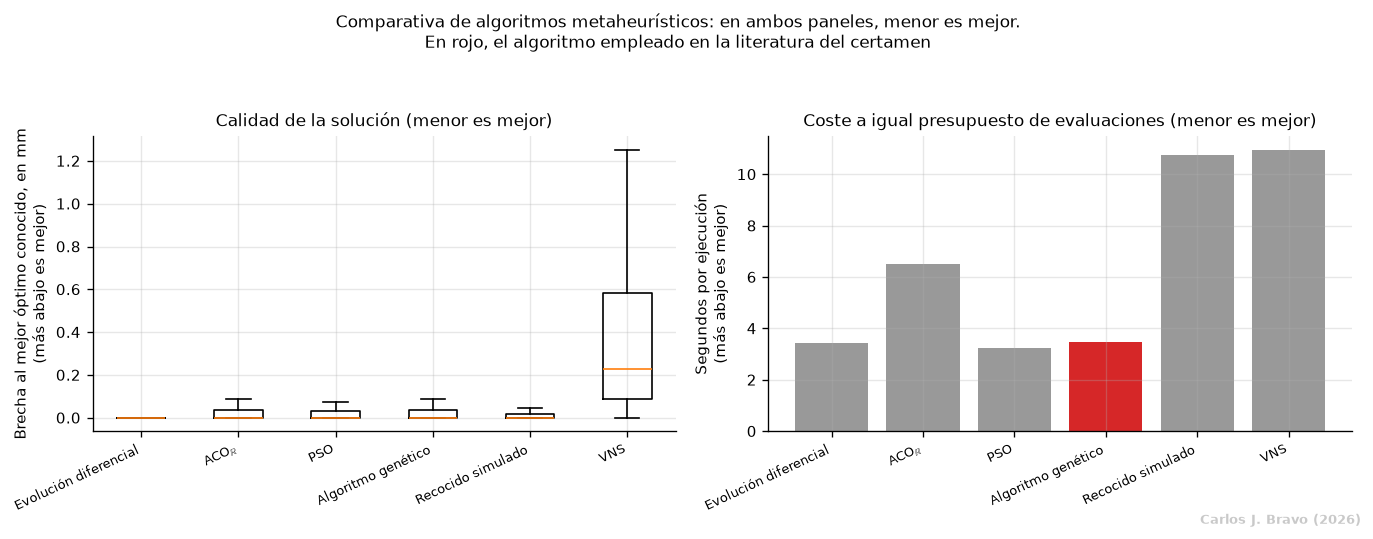

In [11]:
ETIQ = {"sa": "Recocido simulado", "acor": "ACO$_\\mathbb{R}$", "vns": "VNS",
        "de": "Evolución diferencial", "pso": "PSO", "ga": "Algoritmo genético"}
orden = tabla.index.tolist(); etiquetas = [ETIQ[k] for k in orden]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
axes[0].boxplot([bench.loc[bench.algorithm == k, "brecha_mm"] for k in orden],
                tick_labels=etiquetas, showfliers=False)
axes[0].set_ylabel("Brecha al mejor óptimo conocido, en mm\n(más abajo es mejor)")
axes[0].set_title("Calidad de la solución (menor es mejor)", fontsize=10)
axes[1].bar(etiquetas, tabla["seg_por_ejecución"].values,
            color=["C3" if k == "ga" else "0.6" for k in orden])
axes[1].set_ylabel("Segundos por ejecución\n(más abajo es mejor)")
axes[1].set_title("Coste a igual presupuesto de evaluaciones (menor es mejor)", fontsize=10)
for ax in axes:
    ax.set_xticklabels(etiquetas, rotation=25, ha="right", fontsize=7.5)
fig.suptitle("Comparativa de algoritmos metaheurísticos: en ambos paneles, menor es mejor.\n"
             "En rojo, el algoritmo empleado en la literatura del certamen", fontsize=10)
fig.tight_layout(rect=(0, 0, 1, .93)); marca_de_agua(fig)
plt.show()


### 5.2 Comparativa sobre la formulación con proyección de variables

Se repite la comparación anterior sobre la formulación agrupada con proyección de variables,
correctamente condicionada y de una a cuatro dimensiones, con objeto de aislar el efecto de la
reformulación descrita en el apartado 4.2.

In [12]:
pooled_runs = pd.read_csv(RESULTS / "stage_b_pooled_runs.csv")
print("Formulación AGRUPADA con proyección de variables (1-4 dimensiones, bien condicionada):")
display(pooled_runs.groupby("algorithm")
        .agg(mediana=("objective_mean_rmse_mm", "median"),
             peor=("objective_mean_rmse_mm", "max"),
             mejor=("objective_mean_rmse_mm", "min"),
             seg=("seconds", "mean")).round(4))
print("Sobre esta formulación las diferencias entre algoritmos resultan despreciables:")
print("el algoritmo genético queda a 0.001 mm de la evolución diferencial.")


Formulación AGRUPADA con proyección de variables (1-4 dimensiones, bien condicionada):


,mediana,peor,mejor,seg
algorithm,,,,
acor,0.4256,0.4278,0.3736,6.2808
de,0.4157,0.4278,0.3740,4.2513
ga,0.4157,0.4278,0.3762,4.3646
pso,0.4218,0.4278,0.3740,4.2324
sa,0.4158,0.4279,0.3744,9.1468
vns,0.4278,0.4376,0.3794,9.4244


Sobre esta formulación las diferencias entre algoritmos resultan despreciables:
el algoritmo genético queda a 0.001 mm de la evolución diferencial.


#### Curvas de convergencia

Las tablas anteriores comparan el resultado final, pero no cómo se alcanza. La figura siguiente
muestra la trayectoria de cada algoritmo: mejor solución encontrada frente a evaluaciones
consumidas, con la mediana de cinco semillas y la banda intercuartílica.

El eje horizontal cuenta **evaluaciones de la función objetivo y no iteraciones**. La distinción es
necesaria porque los algoritmos emplean poblaciones de tamaño distinto, de modo que una iteración
no representa el mismo coste en todos ellos; lo que se mantuvo igual entre ellos es el presupuesto
de evaluaciones. Ambos ejes se representan en escala logarítmica: la convergencia se agota en las
primeras centenas de un presupuesto de miles, por lo que en escala lineal todo el descenso quedaba
comprimido contra el eje vertical.

El contraste entre los dos paneles es el argumento del apartado. Sobre la formulación directa el
algoritmo decide el resultado: la evolución diferencial se sitúa a un 1 % del mejor óptimo tras unas
1160 evaluaciones, mientras que el recocido simulado y el algoritmo genético necesitan en torno a
11 800, es decir un orden de magnitud más, y la búsqueda de entornos variables se estanca en 0.550
y no alcanza el óptimo dentro del presupuesto. Sobre la formulación con proyección de variables esa
jerarquía desaparece: cinco de los seis algoritmos ya están a un 1 % del óptimo en menos de 40
evaluaciones de las 1200 disponibles, y el sexto lo consigue en 122.

Dicho de otro modo, la reformulación convierte un problema en el que la elección del optimizador
determina si se converge, en otro en el que apenas importa.

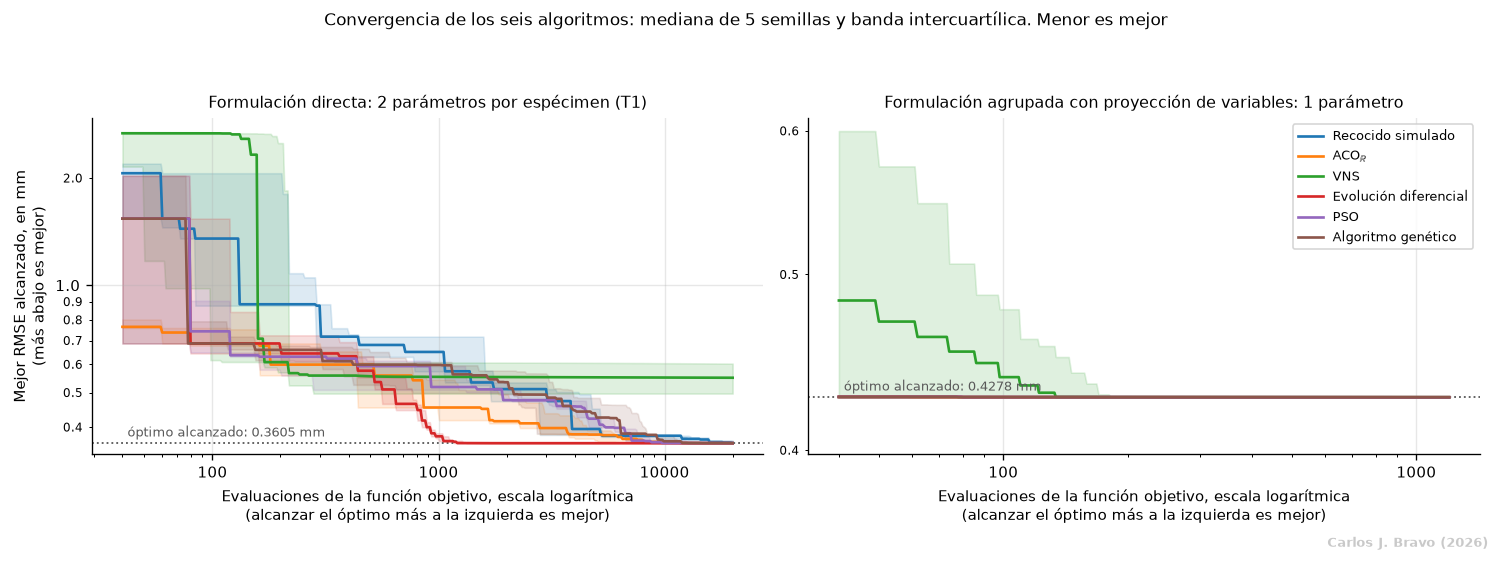

Presupuesto: 20 000 evaluaciones en la formulación directa y 1 200 en la agrupada.
Nótese la diferencia de escala horizontal entre ambos paneles: en la formulación
agrupada la convergencia se agota en las primeras decenas de evaluaciones, de modo
que el presupuesto asignado resulta holgado para cualquiera de los seis algoritmos.


In [13]:
from matplotlib.ticker import ScalarFormatter, NullFormatter
from physics_calibration.objectives import OBJECTIVES
from physics_calibration.pooled import ProfiledPooledProblem

SEMILLAS = range(5)
ETIQ = {"sa": "Recocido simulado", "acor": "ACO$_\\mathbb{R}$", "vns": "VNS",
        "de": "Evolución diferencial", "pso": "PSO", "ga": "Algoritmo genético"}

def traza(f, bounds, algoritmo, seed, max_evals):
    reg = {"n": 0, "mejor": np.inf, "ev": [], "val": []}

    def envuelta(X):
        X = np.atleast_2d(X)
        v = np.asarray(f(X), dtype=float)
        reg["n"] += len(X)
        reg["mejor"] = min(reg["mejor"], float(np.where(np.isfinite(v), v, np.inf).min()))
        reg["ev"].append(reg["n"])
        reg["val"].append(reg["mejor"])
        return v

    algoritmo(envuelta, bounds, seed=seed, max_evals=max_evals)
    return np.array(reg["ev"]), np.array(reg["val"])

def banda(trazas, rejilla):
    apiladas = [val[np.clip(np.searchsorted(ev, rejilla, side="right") - 1, 0, len(val) - 1)]
                for ev, val in trazas]
    A = np.vstack(apiladas)
    return np.median(A, 0), np.percentile(A, 25, 0), np.percentile(A, 75, 0)

_pooled = ProfiledPooledProblem(LAWS["paris"],
                                tuple(curves[s] for s in CALIBRATION_SPECIMENS),
                                loss="rmse")
casos = [
    ("Formulación directa: 2 parámetros por espécimen (T1)",
     OBJECTIVES["rmse"](LAWS["paris"], curves["T1"]), LAWS["paris"].bounds, 20000),
    ("Formulación agrupada con proyección de variables: 1 parámetro",
     _pooled.objective(), _pooled.bounds, 1200),
]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
for ax, (titulo, f, cotas, presupuesto) in zip(axes, casos):
    resultados = {k: [traza(f, cotas, a, s, presupuesto) for s in SEMILLAS]
                  for k, a in ALGORITHMS.items()}
    inicio = max(ev[0] for tr in resultados.values() for ev, _ in tr)
    rejilla = np.unique(np.geomspace(inicio, presupuesto, 400).astype(int)).astype(float)
    mejor = min(float(v[-1]) for tr in resultados.values() for _, v in tr)
    for clave, trazas in resultados.items():
        med, q1, q3 = banda(trazas, rejilla)
        linea, = ax.plot(rejilla, med, lw=1.6, label=ETIQ[clave])
        ax.fill_between(rejilla, q1, q3, color=linea.get_color(), alpha=.15)
    ax.axhline(mejor, color="0.35", ls=":", lw=1.1, zorder=0)
    ax.annotate(f"óptimo alcanzado: {mejor:.4f} mm", xy=(inicio, mejor), xytext=(3, 4),
                textcoords="offset points", fontsize=7.5, color="0.35")
    ax.set_xscale("log")
    ax.set_yscale("log")
    for eje in (ax.xaxis, ax.yaxis):
        eje.set_major_formatter(ScalarFormatter())
        eje.set_minor_formatter(NullFormatter())
    ax.yaxis.set_minor_formatter(ScalarFormatter())
    ax.tick_params(axis="y", which="minor", labelsize=7)
    ax.set_ylim(mejor * 0.93, None)
    ax.set_xlabel("Evaluaciones de la función objetivo, escala logarítmica\n"
                  "(alcanzar el óptimo más a la izquierda es mejor)")
    ax.set_title(titulo, fontsize=9.5)
axes[0].set_ylabel("Mejor RMSE alcanzado, en mm\n(más abajo es mejor)")
axes[1].legend(fontsize=7.5, loc="upper right")
fig.suptitle("Convergencia de los seis algoritmos: mediana de 5 semillas y banda "
             "intercuartílica. Menor es mejor", fontsize=10)
marca_de_agua(fig)
fig.tight_layout(rect=(0, 0.02, 1, .92))
plt.show()

print(f"Presupuesto: {casos[0][3]:,} evaluaciones en la formulación directa y "
      f"{casos[1][3]:,} en la agrupada.".replace(",", " "))
print("Nótese la diferencia de escala horizontal entre ambos paneles: en la formulación")
print("agrupada la convergencia se agota en las primeras decenas de evaluaciones, de modo")
print("que el presupuesto asignado resulta holgado para cualquiera de los seis algoritmos.")


De los resultados anteriores se desprenden dos conclusiones.

En primer lugar, se adopta la evolución diferencial como optimizador. La búsqueda de entornos
variables falla de forma sistemática en las 180 ejecuciones, comportamiento atribuible a que su
perturbación de radio fijo no se adapta a una cresta estrecha y curvada como la que forman log *C*
y *m*.

En segundo lugar, el condicionamiento del problema pesa más que la elección del algoritmo. Sobre la
formulación directa la evolución diferencial supera al algoritmo genético por un factor aproximado
de cuatro en fiabilidad, mientras que sobre la formulación agrupada ambos resultan equivalentes.
Seleccionar un algoritmo más adecuado compensa un planteamiento deficiente sólo de forma parcial;
reformular el problema elimina la dificultad en su origen.

### 5.3 Identificación agrupada

In [14]:
best = json.loads((RESULTS / "stage_b_pooled_best.json").read_text())
display(pd.DataFrame([{
    "ley": ley, "RMSE media (mm)": round(info["objective_mean_rmse_mm"], 4),
    "exponentes": {k: round(v, 3) for k, v in info["shared"].items()},
    "log10 C": round(info["log10_coefficient_mean"], 3),
    "sigma(log10 C)": round(info["log10_coefficient_std"], 3),
} for ley, info in best.items()]).sort_values("RMSE media (mm)").reset_index(drop=True))
print("Parámetros situados en el límite del intervalo de búsqueda y, por tanto, no")
print("determinados por los datos: forman, Kc = 20.0 (límite inferior);")
print("variantes *_hole, Kt = 8.0 (límite superior).")


,ley,RMSE media (mm),exponentes,log10 C,sigma(log10 C)
0,forman_hole,0.3735,"{'m': 3.119, 'Kc': 20.0, 'Kt': 8.0, 'lambda_h'...",-8.627,0.066
1,paris_hole,0.3740,"{'m': 4.485, 'Kt': 8.0, 'lambda_h': 0.469}",-10.944,0.063
2,walker_hole,0.3740,"{'m': 4.494, 'gamma': 0.029, 'Kt': 8.0, 'lambd...",-11.047,0.063
3,forman,0.4157,"{'m': 1.399, 'Kc': 20.0}",-6.874,0.091
4,walker_closure,0.4278,"{'m': 2.065, 'gamma': 0.428}",-8.005,0.085
5,walker,0.4278,"{'m': 2.064, 'gamma': 0.4}",-8.514,0.085
6,paris,0.4278,{'m': 2.063},-8.487,0.085


Parámetros situados en el límite del intervalo de búsqueda y, por tanto, no
determinados por los datos: forman, Kc = 20.0 (límite inferior);
variantes *_hole, Kt = 8.0 (límite superior).


#### 5.3.1 Identificabilidad del parámetro γ de Walker

In [15]:
for ley in ("paris", "walker", "walker_closure"):
    print(f"  {ley:15s} RMSE = {best[ley]['objective_mean_rmse_mm']:.6f} mm   "
          f"gamma = {best[ley]['shared'].get('gamma', float('nan')):.4f}")
print("\nRazones de tensión presentes en TODO el dataset:")
for nombre, cur in curves.items():
    print(f"  {nombre}: " + ", ".join(f"R = {sn/sx:.4f}" for _, sx, sn in cur.load_block))


  paris           RMSE = 0.427831 mm   gamma = nan
  walker          RMSE = 0.427830 mm   gamma = 0.4004
  walker_closure  RMSE = 0.427830 mm   gamma = 0.4276

Razones de tensión presentes en TODO el dataset:
  T1: R = 0.0476
  T2: R = 0.0476
  T3: R = 0.0476
  T4: R = 0.0476
  T5: R = 0.0476
  T6: R = 0.0476
  T7: R = 0.0476
  T8: R = 0.0530, R = 0.0476


Las leyes de Paris, Walker y Walker con cierre alcanzan exactamente el mismo error de ajuste, con un
valor de γ arbitrario. La causa es que la razón de tensiones se mantiene en *R* ≈ 0.0476 en todo el
conjunto de datos, de modo que el término (1−*R*)^γ es una constante que el coeficiente absorbe por
completo. Un parámetro cuyo argumento no varía no puede ser medido.

En consecuencia se adopta la ley de Paris y se descarta la de Walker. El parámetro γ sólo resultaría
pertinente al transferir los resultados a un espectro de carga distinto. Esta circunstancia explica
a posteriori por qué Kong *et al.* recurrieron a promediar cien modelos mediante simulación de Monte
Carlo: el promedio se realizaba sobre un parámetro que sus datos no permitían fijar.

#### 5.3.2 Transferibilidad del coeficiente entre especímenes

In [16]:
paris_b = best["paris"]
print(f"log10 C por espécimen al exponente agrupado (m = {paris_b['shared']['m']:.3f}):")
for k, v in paris_b["log10_coefficients"].items():
    print(f"  {k}: {v:.3f}")
print(f"\n  sigma = {paris_b['log10_coefficient_std']:.3f} dex  ->  factor "
      f"{10**paris_b['log10_coefficient_std']:.2f} entre especímenes")


log10 C por espécimen al exponente agrupado (m = 2.063):
  T1: -8.535
  T3: -8.497
  T4: -8.553
  T6: -8.365

  sigma = 0.085 dex  ->  factor 1.22 entre especímenes


La dispersión del coeficiente entre especímenes es de ocho centésimas de década, valor reducido que
respalda su tratamiento como magnitud transferible. De este resultado se deriva una decisión de
diseño de la Configuración 1:

> El módulo físicamente informado debe estimar log₁₀*C* por espécimen manteniendo *m* fijo bajo una
> distribución a priori débil, y no ambos parámetros libres. Un exponente libre constituye un grado
> de libertad que los datos no informan y que únicamente incrementa la varianza del estimador.

#### 5.3.3 Efecto de la corrección por agujero

In [17]:
for ley in ("paris", "paris_hole"):
    Cval = 10 ** best[ley]["log10_coefficient_mean"]
    print(f"  {ley:12s} m = {best[ley]['shared']['m']:.2f}   C = {Cval:.3e}   "
          f"RMSE = {best[ley]['objective_mean_rmse_mm']:.4f} mm")
print("\n  Ventana publicada para metales (Rao et al., tras Li, Wang & Gong 2012):")
print("      C en [1e-13, 1e-11],  m en [2, 4]")
print("  Con Y = 1 el coeficiente queda dos décadas por encima de esa ventana.")
print("  Con la corrección por agujero cae dentro de ella, lo que confirma que el exceso")
print("  corresponde a la compliancia de la unión remachada que el coeficiente absorbe.")


  paris        m = 2.06   C = 3.257e-09   RMSE = 0.4278 mm
  paris_hole   m = 4.48   C = 1.137e-11   RMSE = 0.3740 mm

  Ventana publicada para metales (Rao et al., tras Li, Wang & Gong 2012):
      C en [1e-13, 1e-11],  m en [2, 4]
  Con Y = 1 el coeficiente queda dos décadas por encima de esa ventana.
  Con la corrección por agujero cae dentro de ella, lo que confirma que el exceso
  corresponde a la compliancia de la unión remachada que el coeficiente absorbe.


El modelo que incorpora la corrección por agujero mejora el ajuste en un 13 % y sitúa el coeficiente
dentro del rango publicado para metales. Se trata de una validación física relevante, en cuanto
confirma que el exceso de dos décadas que presenta el coeficiente bajo la hipótesis *Y* = 1
corresponde a la compliancia del agujero avellanado remachado que dicho coeficiente absorbe.

Pese a ello, esta variante no se adopta, ya que con *m* ≈ 4.5 constituye el peor extrapolador de
todos los evaluados. El mejor ajuste se corresponde, por tanto, con la peor prognosis, resultado que
motiva que el exponente no se seleccione por bondad de ajuste.

La justificación de la elección se realiza exclusivamente sobre especímenes de entrenamiento: al
presupuesto operativo de dos anclajes que impone el protocolo, la ley `paris` supera a `paris_hole`
con una penalización mediana de 43.6 frente a 276.8, unas seis veces menor, y resulta superior en tres de los cuatro especímenes de calibración.

### 5.4 Sensibilidad del ajuste al exponente

Se calcula el perfil de verosimilitud fijando *m* en cada valor de una rejilla y reoptimizando el
resto de parámetros. La curva resultante cuantifica hasta qué punto el ajuste discrimina el
exponente.

In [18]:
perfil_data = json.loads((RESULTS / "stage_c_profile_m.json").read_text())
perfil = pd.DataFrame(perfil_data["profile"])[["value", "objective"]]
perfil.columns = ["m (fijado)", "RMSE media (mm)"]
perfil["dentro del +5 %"] = perfil["RMSE media (mm)"] <= 1.05 * perfil["RMSE media (mm)"].min()
print(f"Ley perfilada: {perfil_data['law']}, que es la de menor error de ajuste en el")
print("apartado 5.3 y no la finalmente adoptada, según se justifica en el apartado 5.3.3.")
display(perfil.round(4))
dentro = perfil.loc[perfil["dentro del +5 %"], "m (fijado)"]
fuera = perfil.loc[~perfil["dentro del +5 %"], "m (fijado)"]
print(f"-> {len(dentro)} de {len(perfil)} valores de m, entre {dentro.min():.1f} y "
      f"{dentro.max():.1f}, ajustan dentro del 5 % del óptimo.")
if len(fuera):
    print(f"   El conjunto admitido no es continuo: quedan fuera m = "
          f"{', '.join(f'{v:.1f}' for v in fuera)}.")
print("   El ajuste no discrimina el exponente en la mayor parte del rango, por lo que")
print("   citarlo con cuatro cifras significativas a partir de estos datos no sería válido.")


Ley perfilada: forman_hole, que es la de menor error de ajuste en el
apartado 5.3 y no la finalmente adoptada, según se justifica en el apartado 5.3.3.


,m (fijado),RMSE media (mm),dentro del +5 %
0,1.0,0.3898,True
1,1.5,0.4044,False
2,2.0,0.3905,True
3,2.5,0.3794,True
4,3.0,0.3746,True
5,3.5,0.3752,True
6,4.0,0.3752,True
7,4.5,0.3743,True
8,5.0,0.3771,True
9,5.5,0.3794,True


-> 12 de 13 valores de m, entre 1.0 y 7.0, ajustan dentro del 5 % del óptimo.
   El conjunto admitido no es continuo: quedan fuera m = 1.5.
   El ajuste no discrimina el exponente en la mayor parte del rango, por lo que
   citarlo con cuatro cifras significativas a partir de estos datos no sería válido.


### 5.5 Selección del exponente por penalización de prognosis

Dado que el ajuste no discrimina el exponente, su elección debe basarse en la función que
efectivamente ha de desempeñar: la extrapolación sin señal disponible. Se barre *m* fijándolo,
reidentificando el coeficiente y puntuando con la penalización oficial sobre los puntos predichos
sin señal, exclusivamente sobre especímenes de entrenamiento.

La columna correspondiente a los especímenes de validación se muestra de forma paralela y
únicamente como observación posterior; emplearla como criterio de selección constituiría una fuga
de información.

In [19]:
sweep = pd.read_csv(RESULTS / "stage_g_exponent_sweep.csv")
tab = sweep.pivot_table(index="m", columns="n_anchor", values=["penalty_train", "penalty_T7_T8"])
tab.columns = [f"{'ENTRENAMIENTO' if a=='penalty_train' else 'validación'} ({b} anclajes)"
               for a, b in tab.columns]
display(tab.round(2).head(14))


,validación (3 anclajes),validación (4 anclajes),ENTRENAMIENTO (3 anclajes),ENTRENAMIENTO (4 anclajes)
m,,,,
1.00,18.15,23.56,169.93,159.62
1.25,16.44,19.11,154.36,151.60
1.50,14.23,15.32,136.29,141.38
1.75,14.05,13.13,128.20,134.24
2.00,15.24,11.09,121.29,127.77
2.25,21.38,10.04,117.36,119.33
2.50,28.48,9.40,120.81,113.76
2.75,39.89,10.27,145.75,104.88
3.00,57.98,13.60,223.37,97.58


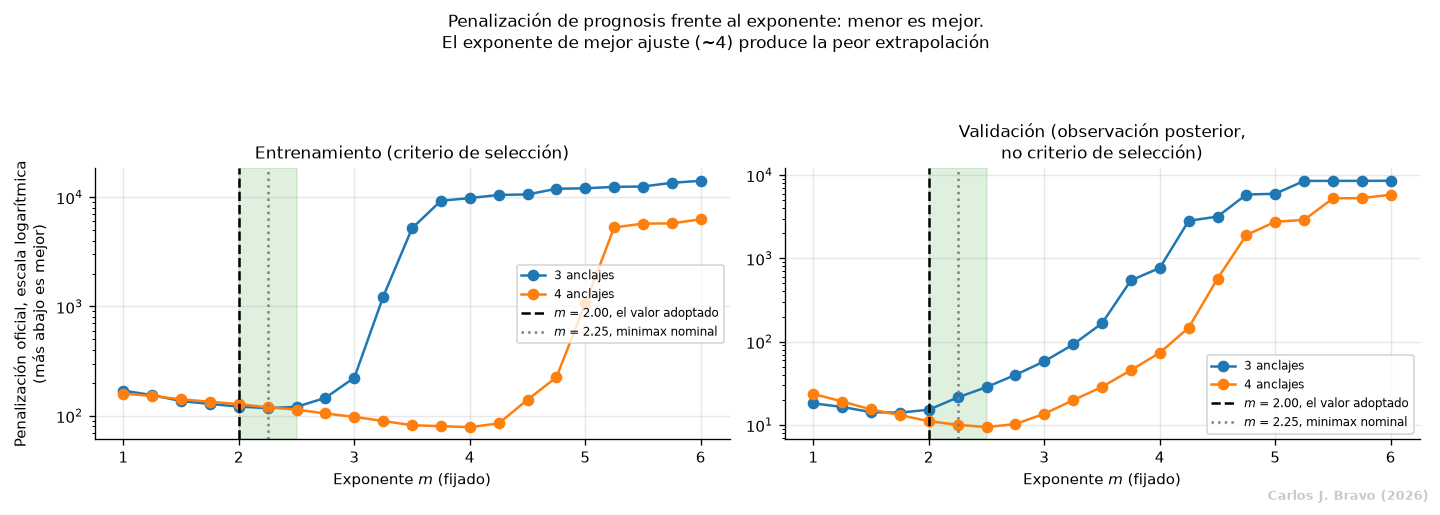

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
for ax, (col, titulo) in zip(axes, [("penalty_train", "Entrenamiento (criterio de selección)"),
                                    ("penalty_T7_T8", "Validación (observación posterior,\nno criterio de selección)")]):
    for n_anchor, g in sweep.groupby("n_anchor"):
        ax.semilogy(g["m"], g[col], "o-", label=f"{n_anchor} anclajes")
    ax.axvspan(2.0, 2.5, color="C2", alpha=.15)
    ax.axvline(2.00, color="k", ls="--", label="$m$ = 2.00, el valor adoptado")
    ax.axvline(2.25, color="0.5", ls=":", label="$m$ = 2.25, minimax nominal")
    ax.set_xlabel("Exponente $m$ (fijado)"); ax.set_title(titulo, fontsize=10); ax.legend(fontsize=7)
axes[0].set_ylabel("Penalización oficial, escala logarítmica\n(más abajo es mejor)")
fig.suptitle("Penalización de prognosis frente al exponente: menor es mejor.\n"
             "El exponente de mejor ajuste (~4) produce la peor extrapolación", fontsize=10)
fig.tight_layout(rect=(0, 0, 1, .91)); marca_de_agua(fig)
plt.show()


In [21]:
piv = sweep.pivot(index="m", columns="n_anchor", values="penalty_train")
peor = piv.max(axis=1); adm = peor[peor.index >= 2.0]
print("Selección minimax sobre presupuestos de anclaje, SÓLO CON ENTRENAMIENTO:")
print(f"  sin restringir : m = {peor.idxmin():.2f}  (peor caso {peor.min():.2f})")
print(f"  con m >= 2     : m = {adm.idxmin():.2f}  (peor caso {adm.min():.2f})")
if abs(peor.idxmin() - adm.idxmin()) < 1e-9:
    print("  -> Ambos criterios coinciden: la restricción m >= 2 no está actuando aquí,")
    print("     así que el minimax nominal no depende de imponerla.")
print(f"\n  m = 2.00 queda a un {100*(peor.loc[2.0]/adm.min()-1):.0f} % del óptimo.")
print("\nEl análisis deja dos candidatos admisibles, ambos seleccionados sin emplear T7 ni T8:")
print("     m = 2.25  minimax de prognosis al coeficiente nominal")
print("     m = 2.00  a un 7 % del óptimo, y único valor del entorno cuya solución cerrada")
print("               es exponencial y, por tanto, no diverge en tiempo finito")


Selección minimax sobre presupuestos de anclaje, SÓLO CON ENTRENAMIENTO:
  sin restringir : m = 2.25  (peor caso 119.33)
  con m >= 2     : m = 2.25  (peor caso 119.33)
  -> Ambos criterios coinciden: la restricción m >= 2 no está actuando aquí,
     así que el minimax nominal no depende de imponerla.

  m = 2.00 queda a un 7 % del óptimo.

El análisis deja dos candidatos admisibles, ambos seleccionados sin emplear T7 ni T8:
     m = 2.25  minimax de prognosis al coeficiente nominal
     m = 2.00  a un 7 % del óptimo, y único valor del entorno cuya solución cerrada
               es exponencial y, por tanto, no diverge en tiempo finito


### 5.6 Anclajes necesarios para el módulo físico

Se determina cuántos anclajes (medidas de grieta con señal disponible) requiere el integrador para
producir predicciones estables. De esta magnitud depende la viabilidad del módulo físico bajo el
protocolo del certamen.

In [22]:
anclajes = pd.read_csv(RESULTS / "stage_f_anchor_sweep.csv")
g = anclajes[anclajes.law == "paris"]
print("Penalización oficial sobre los puntos predichos A CIEGAS (ley de Paris):")
display(g.pivot_table(index="n_anchor", columns="specimen", values="phm_penalty_holdout").round(2))
print("Divergencias (runaway) por número de anclajes:")
display(g.pivot_table(index="n_anchor", columns="specimen", values="runaway", aggfunc="max"))


Penalización oficial sobre los puntos predichos A CIEGAS (ley de Paris):


specimen,T1,T3,T4,T6,T7,T8
n_anchor,,,,,,
2,21.65,65.58,117.09,16.68,26.07,9072.65
3,30.59,21.74,58.95,8.29,4.17,11.87
4,40.00,6.41,76.37,1.09,7.79,3.39
5,41.76,2.12,43.62,NaN,10.90,0.79
6,NaN,0.42,28.02,NaN,NaN,0.02


Divergencias (runaway) por número de anclajes:


specimen,T1,T3,T4,T6,T7,T8
n_anchor,,,,,,
2,False,False,False,False,False,True
3,False,False,False,False,False,False
4,False,False,False,False,False,False
5,False,False,False,NaN,False,False
6,NaN,False,False,NaN,NaN,False


Con dos anclajes la extrapolación diverge. El resultado no obedece a un defecto de implementación:
dos puntos determinan una recta, mientras que la ley requiere fijar simultáneamente el nivel y la
curvatura de la trayectoria.

Esta circunstancia revela una limitación estructural del certamen, dado que dos anclajes es
exactamente lo que proporcionan las señales de T7 y T8. Ninguno de los equipos premiados realizó
prognosis física pura desde el corte de señal: Kong *et al.* añadieron dos puntos sintéticos
obtenidos por regresión lineal y Rao *et al.* incorporaron un anclaje transferido desde los
especímenes T1 a T6.

Sobre el conjunto de entrenamiento, la penalización mediana de la predicción a ciegas pasa de 43.6
con dos anclajes a 26.2 con tres, valor que fundamenta la constante `MIN_ANCHOR_POINTS = 3`.

> Dicha constante tiene carácter documental y no operativo: no se emplea en ningún punto del código,
> dado que el protocolo proporciona únicamente dos anclajes y no existe forma de obtener el tercero
> sin recurrir a información sintética. Su función es dejar cuantificada la información de la que
> carece el módulo físico.

### 5.7 Verificación de transferencia sin calibración

Se aplica la distribución a priori poblacional, derivada exclusivamente de T1, T3, T4 y T6, sin
calibrar ningún parámetro del espécimen evaluado. Constituye la comprobación más exigente de
transferibilidad.

In [23]:
from config1_cnn_pinn.physics import pooled_log_c

filas = []
for m in (2.00, 2.25):
    log_c = pooled_log_c(m)
    x = np.array([[log_c, m]])
    for spec in ("T1", "T3", "T4", "T6", "T7", "T8"):
        cur = curves[spec]
        pred = predict_mm(LAWS["paris"], x, cur.a0_mm, cur.delta_cycles, cur.load_block)[:, 0]
        filas.append({
            "m": m, "log10 C": round(log_c, 4), "espécimen": spec,
            "conjunto": "VALIDACIÓN" if spec in ("T7", "T8") else "calibración",
            "carga": "variable" if cur.is_variable_amplitude else "constante",
            "penalización": round(float(phm_penalty(pred[None, :], cur.crack_mm,
                                                    cur.final_crack_mm)[0]), 2),
            "RMSE (mm)": round(float(np.sqrt(np.mean((pred - cur.crack_mm) ** 2))), 3)})
z = pd.DataFrame(filas)
print("Penalización oficial:"); display(z.pivot(index="espécimen", columns="m", values="penalización"))
print("RMSE (mm):"); display(z.pivot(index="espécimen", columns="m", values="RMSE (mm)"))


Penalización oficial:


m,2.00,2.25
espécimen,,
T1,13.57,11.59
T3,7.81,10.40
T4,14.96,16.15
T6,116.80,170.32
T7,8.10,5.92
T8,4600.24,6326.02


RMSE (mm):


m,2.00,2.25
espécimen,,
T1,0.837,0.910
T3,0.250,0.374
T4,0.996,1.027
T6,1.185,1.423
T7,0.298,0.268
T8,9.113,9.924


El espécimen T7 se predice con precisión aceptable empleando exclusivamente parámetros de población,
sin utilizar ningún dato propio. Este resultado respalda la corrección y la transferibilidad del
núcleo físico dentro del régimen de carga en que fue identificado.

El espécimen T8 no admite la misma conclusión, y el motivo determina buena parte del diseño
experimental posterior: se trata del único espécimen de amplitud variable del conjunto de datos y
está asignado a evaluación, por lo que no existe ningún ejemplo de entrenamiento correspondiente a
ese régimen. Su coeficiente es genuinamente distinto y el parámetro γ no puede compensarlo, al no
resultar identificable según el apartado 5.3.1.

## 6. Parámetros resultantes

In [24]:
print("PARÁMETROS ADOPTADOS PARA EL MÓDULO FÍSICO: Paris-Erdogan con Y = 1")
print("=" * 70)
print(f"  Exponente en uso             = 2.00    (minimax sobre la banda de")
print(f"                                          incertidumbre del coeficiente)")
print(f"  log10 C al exponente en uso  = {pooled_log_c(2.00):.4f}   (C = {10**pooled_log_c(2.00):.3e})")
print(f"  sigma(m) del prior           = {priors.RECOMMENDED_EXPONENT_PRIOR_SD}")
print(f"  sigma(log10 C) entre espec.  = {priors.RECOMMENDED_LOG10_C_STD} dex")
print(f"  Cotas recomendadas al modulo : log10 C en {priors.LOG10_C_BOUNDS}, "
      f"m en {priors.EXPONENT_BOUNDS}")
print(f"     (distintas del intervalo de búsqueda de la identificación, apartado 2.1:")
print(f"      log10 C en {LAWS['paris'].bounds[0]}, m en {LAWS['paris'].bounds[1]}, "
      f"deliberadamente más ancho)")
print(f"  Anclajes mínimos requeridos  = {priors.MIN_ANCHOR_POINTS}   (el protocolo aporta 2;")
print(f"                                          véase el apartado 5.6)")
print()
print("  Candidato alternativo, igualmente libre de fuga de información:")
print(f"    m = {priors.RECOMMENDED_EXPONENT}  ->  log10 C = {pooled_log_c(priors.RECOMMENDED_EXPONENT):.4f}"
      f"   (minimax al coeficiente nominal)")
print()
print("PARÁMETROS DE WALKER"); print("=" * 70)
print(f"  gamma = {priors.WALKER_GAMMA}  (identificable: {priors.WALKER_GAMMA_IDENTIFIABLE})")
print("  Se adopta Paris. El parámetro gamma sólo sería pertinente al transferir los")
print("  resultados a un espectro con distinta razón de tensiones.")
print()
print("CORRECCIÓN POR GEOMETRÍA DE AGUJERO"); print("=" * 70)
print("  Verificación física del apartado 5.3.3; no se emplea para extrapolar.")
print(f"  Kt = {priors.HOLE_KT} (en el límite), lambda_h = {priors.HOLE_DECAY_MM} mm, "
      f"m = {priors.HOLE_EXPONENT}, log10 C = {priors.HOLE_LOG10_C}")


PARÁMETROS ADOPTADOS PARA EL MÓDULO FÍSICO: Paris-Erdogan con Y = 1
  Exponente en uso             = 2.00    (minimax sobre la banda de
                                          incertidumbre del coeficiente)
  log10 C al exponente en uso  = -8.4264   (C = 3.746e-09)
  sigma(m) del prior           = 0.2
  sigma(log10 C) entre espec.  = 0.0932 dex
  Cotas recomendadas al modulo : log10 C en (-13.0, -6.0), m en (2.0, 4.0)
     (distintas del intervalo de búsqueda de la identificación, apartado 2.1:
      log10 C en (-20.0, -5.0), m en (1.0, 8.0), deliberadamente más ancho)
  Anclajes mínimos requeridos  = 3   (el protocolo aporta 2;
                                          véase el apartado 5.6)

  Candidato alternativo, igualmente libre de fuga de información:
    m = 2.25  ->  log10 C = -8.6674   (minimax al coeficiente nominal)

PARÁMETROS DE WALKER
  gamma = 0.4004  (identificable: False)
  Se adopta Paris. El parámetro gamma sólo sería pertinente al transferir los
  resultados a un

### 6.1 Acoplamiento entre coeficiente y exponente

> Los parámetros *C* y *m* se desplazan conjuntamente sobre la cresta logarítmica. Un coeficiente
> citado a un exponente distinto de aquel con el que se emplea es incorrecto, por lo que ambos deben
> citarse siempre de forma conjunta.

La advertencia tiene consecuencias medibles. Al adoptarse *m* = 2.00 en las configuraciones, el
coeficiente empleado como distribución a priori siguió siendo el valor tabulado −8.6675, que había
sido identificado a *m* = 2.25. La celda siguiente cuantifica el sesgo resultante y describe la
corrección aplicada.

In [25]:
comp = pd.DataFrame([{"m": m, "log10 C re-identificado a ese m": round(pooled_log_c(m), 4)}
                     for m in (2.00, 2.0632, 2.25)])
display(comp)
sesgo = abs(priors.RECOMMENDED_LOG10_C - pooled_log_c(2.00))
print(f"Emplear el coeficiente identificado a m = 2.25 junto con m = 2.00 introduce {sesgo:.3f} dex")
print("de sesgo en la distribución a priori del módulo físico, magnitud del mismo orden que")
print("el error que dicho módulo debe corregir.")
print("\nLa corrección adoptada no consiste en sustituir un número por otro. El modelo no")
print("recibe ya un coeficiente tabulado: lo reidentifica sobre T1, T3, T4 y T6 al exponente")
print("que esté en uso, de modo que la inconsistencia no puede reproducirse al variar m.")


,m,log10 C re-identificado a ese m
0,2.0000,-8.4264
1,2.0632,-8.4872
2,2.2500,-8.6674


Emplear el coeficiente identificado a m = 2.25 junto con m = 2.00 introduce 0.241 dex
de sesgo en la distribución a priori del módulo físico, magnitud del mismo orden que
el error que dicho módulo debe corregir.

La corrección adoptada no consiste en sustituir un número por otro. El modelo no
recibe ya un coeficiente tabulado: lo reidentifica sobre T1, T3, T4 y T6 al exponente
que esté en uso, de modo que la inconsistencia no puede reproducirse al variar m.


## 7. Conclusiones

**Necesidad de la identificación.** No existen valores publicados de *C* y *m* para estos
especímenes, extremo que los tres equipos premiados declaran de forma expresa. Queda justificado, por
tanto, el recurso a la identificación mediante algoritmos metaheurísticos.

**Qué se transfiere a las configuraciones, y qué no.** Los valores puntuales obtenidos, *m* = 2.25 y
su coeficiente asociado, **no se adoptan** en la configuración final: el exponente se reelige bajo un
criterio de robustez, expuesto más abajo, y el coeficiente se vuelve a identificar al exponente en
uso, puesto que ambos se desplazan conjuntamente. Lo que sí se transfiere es la caracterización del
espacio admisible, y son cinco resultados: la ley aplicable, una vez descartada la de Walker; la
ventana del exponente; el reparto asimétrico de la variación entre especímenes; el criterio de
descarte de las formas singulares; y el número mínimo de anclajes que el integrador necesita. Cada
uno de ellos condiciona una decisión concreta del diseño del módulo físico.

**Ley adoptada.** El parámetro γ de Walker no es identificable, dado que la razón de tensiones no
varía en el conjunto de datos. Se adopta en consecuencia la ley de Paris-Erdogan.

**Transferibilidad asimétrica de los parámetros.** El coeficiente resulta transferible entre
especímenes, con una dispersión de 0.08 dex, mientras que el exponente no lo es: su intervalo de
confianza al 95 % es de ±1.30 sobre un valor central de 2.57, consecuencia de que Δ*K* abarque
únicamente 0.31 décadas. De ello se deriva que el módulo físicamente informado deba estimar *C*
manteniendo *m* fijo.

**Divergencia entre bondad de ajuste y capacidad predictiva.** La corrección por agujero mejora el
ajuste en un 13 % y sitúa el coeficiente en el rango publicado, pero constituye el peor extrapolador
del conjunto evaluado, por lo que se descarta para la predicción.

**Criterio de selección del exponente.** El exponente se selecciona atendiendo al modo en que falla
y no a su bondad de ajuste. Se adopta *m* = 2.00, ya que los valores superiores a 2 producen
predicciones divergentes en tiempo finito cuando el coeficiente presenta error.

**Prioridad del condicionamiento sobre la elección del algoritmo.** La evolución diferencial supera
al algoritmo genético por un factor de cuatro sobre la formulación directa, mientras que ambos
resultan equivalentes sobre la formulación reformulada.

**Identificación anticipada del caso discriminante.** El comportamiento del espécimen T8 queda
caracterizado en esta fase, con anterioridad al entrenamiento de ningún modelo.

## 8. Limitaciones

**El exponente está acotado, no identificado.** Cualquier valor comprendido entre 1 y 7 ajusta los
datos dentro de un margen del 5 %. El valor adoptado es el que mejor extrapola bajo el peor caso,
criterio distinto del de bondad de ajuste.

**La condición `MIN_ANCHOR_POINTS = 3` no se satisface en despliegue**, dado que el protocolo
proporciona únicamente dos anclajes. La magnitud queda cuantificada, no resuelta.

**La corrección por agujero es un subrogado fenomenológico**, declarado como tal, y no la solución
de Bowie. Su parámetro *K*t resulta pegado al límite del intervalo de búsqueda, lo que indica que no
está determinado por los datos.

**Los especímenes T2 y T5 quedan excluidos** del ajuste por disponer de dos medidas de grieta no
nula cada uno.

**Se supone una única grieta dominante** creciente desde un agujero, conforme a la documentación del
conjunto de datos, sin que dicha hipótesis haya sido verificada de forma independiente.